# **ENGG680 - Introduction to Digital Engineering**
## *Final Project: Predicting Diabetes Progression using Random Forest, Logistic Regression, and SVM Classifier*

## Preliminary: Certificate of Work


*We, the undersigned, certify that this is our own work, which has been done expressly for this course, either without the assistance of any other party or where appropriate we have acknowledged the work of others. Further, we have read and understood the section in the university calendar on plagiarism/cheating/other academic misconduct and we are aware of the implications thereof. We request that the total mark for this assignment be distributed as follows among group members:*

|          | First Name | Last Name | Signature (Full Name, Date) | Hours | Contribution % |
|----------|------------|-----------|-----------------------------|-------|----------------|
| Member 1: | Syed Muhammad Haider Raza | Rizvi |Syed Muhammad Haider Raza Rizvi, 22nd November 2025 | 15 | 25 |
| Member 2: | First Name | Last Name | Signature | Hours | Contribution |
| Member 3: | First Name | Last Name | Signature | Hours | Contribution |
| Member 4: | First Name | Last Name | Signature | Hours | Contribution |


## Step 0: Importing the necessary files

In [1]:
#import necessary libraries
#includes all libraries that will be needed to implement machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, log_loss, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

print('all libraries imported')

all libraries imported


# Step 1: Adding data as a Pandas Dataframe

In [10]:
#import data as a dataframe
data = pd.read_csv('diabetic_data.csv') #[1]

#print shape
print(data.shape) #tells us the rows and columns in the raw data



# dataset obtained from UCI Diabetes 130 US hospitals dataset: 
# [1] J. Clore, K. Cios, J. DeShazo, and B. Strack. "Diabetes 130-US Hospitals for Years 1999-2008," 
# UCI Machine Learning Repository, 2014. [Online]. Available: https://doi.org/10.24432/C5230J.

print('dataset successfully imported')

#view data
data.head()

(101766, 50)
dataset successfully imported


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


# Step 2: Data Preprocessing and defining a target variable

*Target variable: readmission* ->
This target variable will be used to predict progression, that is, if the patient is readmitted then it indicates progression

* Step 2.1.1: removing unnecessary columns

In [11]:
#data preprocessing

# first step here is to remove any column that does not provide any value for the task at hand
# this involves getting all the column names first and then checking them what kind of data they store
# next step involves dropping the extra columns and updating the dataframe


#getting column names:
list(data.columns)

#columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 
# 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 
# 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses',
#  'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 
# 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', # 'insulin', 
# 'glyburide-metformin', # 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

cols_to_remove = ['encounter_id', 'patient_nbr', 'payer_code', 'medical_specialty',
    'acetohexamide','tolbutamide', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'diag_1', 'diag_2', 'diag_3']

df = data.drop(columns=cols_to_remove) #removing extra unnecessary columns
print(list(df.columns))

print('unnecessary columns removed')

['race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']
unnecessary columns removed


* Step 2.1.2: Extract target variable

In [12]:
# the target variable is used to predict progression
# objective is to separate it from the feature matrix so that any encoding or processing step does not significantly impact it.
# "readmission" is used as target variable since it indicates that a patient was readmitted after being discharged since their situation worsened

y = df['readmitted'] #extracting target variable
df = df.drop(columns=['readmitted']) #removing the target variable from the feature matrix

print('target variable extracted')

target variable extracted


* Step 2.2: handling missing values

In [13]:
# handling missing values depend on whether it is a numerical column or a categorical column
# an alternative approach would be to remove the missing rows

df = df.fillna(df.median(numeric_only=True)) #fill the missing values with the median in a numeric column
df = df.fillna(df.mode().iloc[0]) #fill missing columns with the most commonly occuring value

print('missing values handled')

missing values handled


* Step 2.2.1: Handling the weight column

In [14]:
# the weight column in this dataset presents a serious challenge
# it includes ranges but majority of the values in this column have garbage value "?"

# the first step is to replace the trash value with a null. then get the count of the unique values stored in this column

df['weight'] = df['weight'].replace('?',np.nan)
print(df['weight'].value_counts(dropna=False))

# Since missing values: 98569, therefore the weight column will be dropped as this is (98569/101766) approximately 97% of the entire data.
df = df.drop(columns = ['weight'])


# weight column dropped as this will only add noise to the machine learning model. it is not adding any value
print('weight column dropped')

df

weight
NaN          98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64
weight column dropped


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,acarbose,miglitol,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,No
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,No,Yes
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,No,Up,No,No,No,No,No,Ch,Yes
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,No,Steady,No,No,No,No,No,Ch,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,AfricanAmerican,Male,[70-80),1,3,7,3,51,0,16,...,No,No,Down,No,No,No,No,No,Ch,Yes
101762,AfricanAmerican,Female,[80-90),1,4,5,5,33,3,18,...,No,No,Steady,No,No,No,No,No,No,Yes
101763,Caucasian,Male,[70-80),1,1,7,1,53,0,9,...,No,No,Down,No,No,No,No,No,Ch,Yes
101764,Caucasian,Female,[80-90),2,3,7,10,45,2,21,...,No,No,Up,No,No,No,No,No,Ch,Yes


* Step 2.2.2: Handling the age column

In [15]:
#The age column contains ranges instead of a singular numeric value, therefore we have to process it such that it contains a singular numeric value (preferably mean)
# The column contains text so we have to convert that into numbers first
# Then we have to take the range extremes as two separate values and compute a mean
# finally we store it back into the dataframe
# all of this is done in a signle line of code

df['age'] = df['age'].str.extract(r'(\d+)-(\d+)').astype(int).mean(axis=1)

print('age column resolved')

df

age column resolved


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,acarbose,miglitol,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,Caucasian,Female,5.0,6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,No
1,Caucasian,Female,15.0,1,1,7,3,59,0,18,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,AfricanAmerican,Female,25.0,1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,No,Yes
3,Caucasian,Male,35.0,1,1,7,2,44,1,16,...,No,No,Up,No,No,No,No,No,Ch,Yes
4,Caucasian,Male,45.0,1,1,7,1,51,0,8,...,No,No,Steady,No,No,No,No,No,Ch,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,AfricanAmerican,Male,75.0,1,3,7,3,51,0,16,...,No,No,Down,No,No,No,No,No,Ch,Yes
101762,AfricanAmerican,Female,85.0,1,4,5,5,33,3,18,...,No,No,Steady,No,No,No,No,No,No,Yes
101763,Caucasian,Male,75.0,1,1,7,1,53,0,9,...,No,No,Down,No,No,No,No,No,Ch,Yes
101764,Caucasian,Female,85.0,2,3,7,10,45,2,21,...,No,No,Up,No,No,No,No,No,Ch,Yes


* Step 2.3: Encode categorical columns

In [ ]:
df.dtypes #tells us that the columns are of two types: int or object

#find all columns of type object and assign them to a list
categorical_columns = df.select_dtypes(include=['object']).columns.to_list() #extracts columns of data type 'object' and stores them as a list


#handle missing values in these columns
df[categorical_columns] = df[categorical_columns].replace('?',np.nan)

#trying to find which column has binary values and which has multi-class values
# as the encoding method that will be used depends on this
binary_col = []
multi_class_col = []
for col in categorical_columns:
    print(col, df[col].nunique()) #prints the name of the column and the number of unique values in it
    num_unique = df[col].nunique() #stores the number of unique values in the categorical columns
    if num_unique == 2:
        binary_col.append(col) #stores categorical column names that have 2 unique values, hence is binary
    else:
        multi_class_col.append(col) #stores categorical column names that have more than 2 (there's no column with less than 2 values)

print('binary: ',binary_col)
print('multi class: ',multi_class_col)


#use LabelEncoder for binary columns

labelencoder = LabelEncoder()
for col in binary_col:
    if col in df.columns:
        df[col] = labelencoder.fit_transform(df[col]) #converted the textual variables into numbers

#use one-hot encoding for multi-class columns, creates new duplicate columns that contain binary values.
df = pd.get_dummies(df, multi_class_col,drop_first=True)
df.info() #gives the final state after encoding has been done. 
# it will show that the number of columns has increased, which is normal, since one hot encoding created duplicates


race 5
gender 3
max_glu_serum 3
A1Cresult 3
metformin 4
repaglinide 4
nateglinide 4
chlorpropamide 4
glimepiride 4
glipizide 4
glyburide 4
pioglitazone 4
rosiglitazone 4
acarbose 4
miglitol 4
insulin 4
glyburide-metformin 4
glipizide-metformin 2
glimepiride-pioglitazone 2
metformin-rosiglitazone 2
metformin-pioglitazone 2
change 2
diabetesMed 2
binary:  ['glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']
multi class:  ['race', 'gender', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'insulin', 'glyburide-metformin']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 67 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   age                       

* Step 2.4: Encode target variable

In [ ]:
# readmitted column has three values: >30, <30, and NO which translates to "readmitted after 30 days","readmitted under 30 days", and "not readmitted"
# we have used the readmitted column as our target variable since this is readmission into the hospital shows that the disease has progressed
# we can consider >30 and <30 to be 1 and NO to be 0. 

y_binary = y.replace({
    '>30':1,
    '<30':1,
    'NO':0
})
y_binary

C:\Users\Syed Rizvi\AppData\Local\Temp\ipykernel_42832\344751258.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_binary = y.replace({


0         0
1         1
2         0
3         0
4         0
         ..
101761    1
101762    0
101763    0
101764    0
101765    0
Name: readmitted, Length: 101766, dtype: int64

* Step 2.5: Class Label Histogram

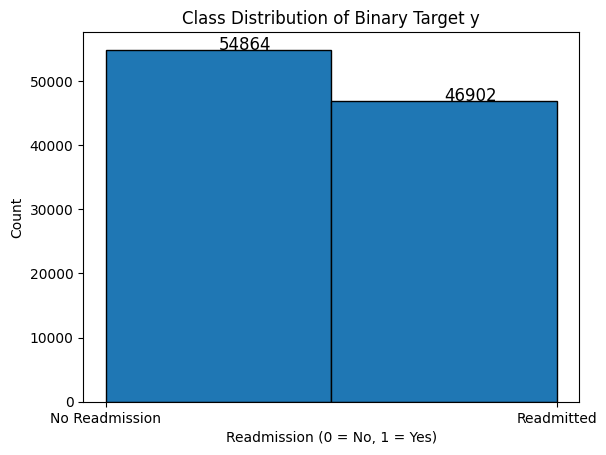

In [ ]:
# Check the class distribution of y
# this is to check if the target variable is balanced or not.


# Display exact values for each bin in the histogram
# Plot class distribution for binary target
count, bins, patches = plt.hist(y_binary, bins=2, edgecolor='black')

# Display counts on top of bars
for i in range(len(count)):
    plt.text(bins[i] + 0.25, count[i], int(count[i]), fontsize=12)

plt.title('Class Distribution of Binary Target y')
plt.xlabel('Readmission (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Readmission', 'Readmitted'])
plt.show()


* The target variable has a split of (54864/101766) 53.9% not readmitted and (46902/101766) 46.1% readmitted. It can be considered a balanced dataset since the target variable has an almost even split and does not seem to heavily favor a specific class.

* Step 2.6: Train-Test Split

In [12]:
#train-test split using 80/20 distribution
X_train, X_test, y_train, y_test = train_test_split(df,y_binary, test_size = 0.2, random_state = 42, stratify=y_binary)

#using stratify for y_binary reproduces the same class split in training and testing data

print('Size of X_train: ',X_train.shape)
print('Size of X_test: ',X_test.shape)

print('Class distribution of y_train: ',y_train.value_counts(normalize=True))
print('Class distribution of y_test: ',y_test.value_counts(normalize=True))


Size of X_train:  (81412, 67)
Size of X_test:  (20354, 67)
Class distribution of y_train:  readmitted
0    0.539122
1    0.460878
Name: proportion, dtype: float64
Class distribution of y_test:  readmitted
0    0.539108
1    0.460892
Name: proportion, dtype: float64


# Step 3: Scaling and Standardization

In [ ]:
from sklearn.preprocessing import StandardScaler

#scaling is especially important for SVM

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


#X_train_scaled.mean(axis=0)
#X_train_scaled.std(axis=0)

# Step 4: Building Models

* Step 4.1: Builing the Logistic Regression Model and Training

In [14]:
#using the train-test data above, training the logistic regression model

model = LogisticRegression(max_iter=2000)
model.fit(X_train_scaled, y_train) #training model with data

y_pred_prob_LogReg = model.predict_proba(X_test_scaled) #testing model
y_pred_LogReg = model.predict(X_test_scaled) #predicted value

#print('Testing values: ', y_test) #y_test stores the true values
print('Predicted values: ',y_pred_LogReg)

Predicted values:  [0 0 0 ... 0 1 0]


* Step 4.2: Building the SVM Classifier and Training

In [ ]:
# values are already scaled
# using linear kernel instead of the default rbf for faster processing
'''
svmModel = SVC(kernel='linear',C=1.0,probability=True,random_state=42)
svmModel.fit(X_train_scaled,y_train)

y_pred_SVM = svmModel.predict(X_test_scaled)
y_proba_SVM = svmModel.predict_proba(X_test_scaled)

print('Predicted values: ',y_pred_SVM)

'''

#had to use linearSVC for faster processing, regular SVM took a long time.
#SVM processing depends on processor speed therefore using LinearSVC cut down the processing time significantly.
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

base_svm = LinearSVC(random_state=42)

svmModel = CalibratedClassifierCV(base_svm)
svmModel.fit(X_train_scaled, y_train)

y_pred_SVM = svmModel.predict(X_test_scaled)
y_proba_SVM = svmModel.predict_proba(X_test_scaled)

* Step 4.3: Building the Random Forest Model and Training

In [ ]:
RFModel = RandomForestClassifier(n_estimators=200,max_depth=None, random_state=42) #chose an arbitrary number of 200 trees. can be altered.
RFModel.fit(X_train_scaled,y_train)

y_pred_RFC = RFModel.predict(X_test_scaled)
y_proba_RFC = RFModel.predict_proba(X_test_scaled)

# Step 5: Accuracy Evaluation

In [18]:
#creating a dictionary for easy evaluation
models = {
    "Logistic Regression": y_pred_LogReg,
    "Random Forest": y_pred_RFC,
    "SVM": y_pred_SVM
}

* Step 5.1: Confusion Matrices

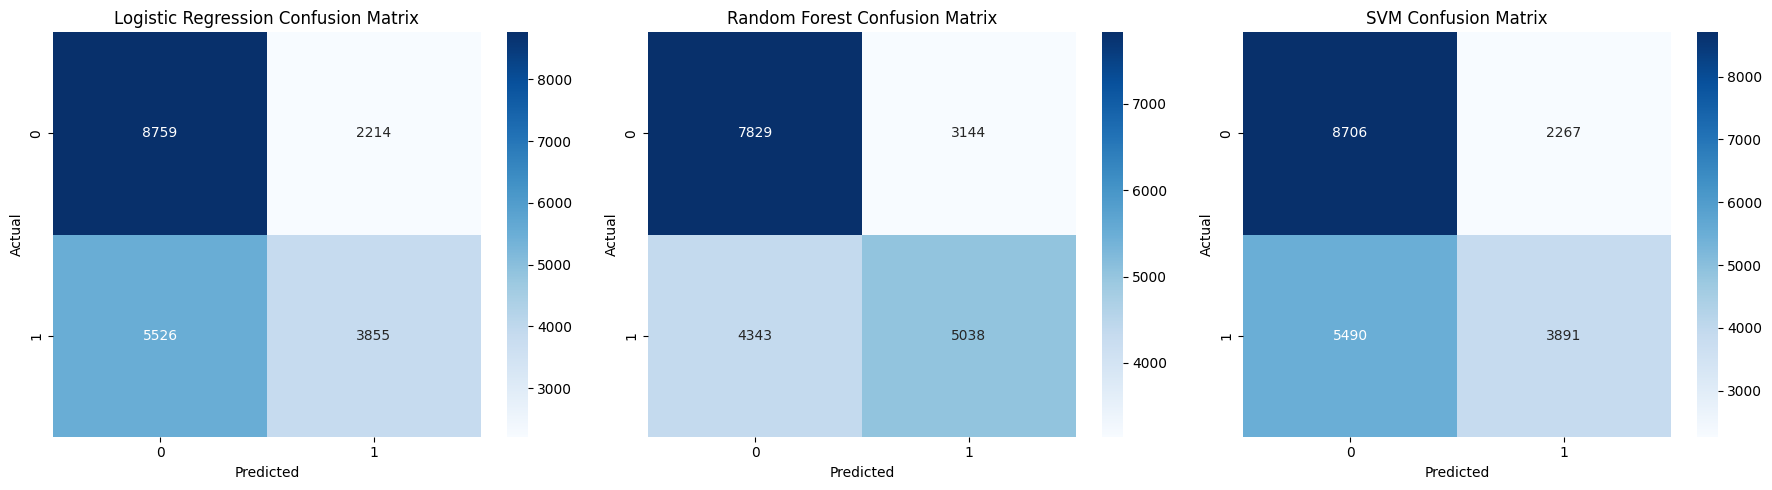

In [ ]:
#creating subplots to view the confusion matrices side by side

fig, ax = plt.subplots(1,3, figsize=(18,5))

for i, (name, preds) in enumerate(models.items(), 1):
    cm = confusion_matrix(y_test, preds)
    
    plt.subplot(1, 3, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

* Step 5.2: Precision, Accuracy, Recall, F1-Score

In [ ]:
#evaluting model precision, accuracy, recall, F1-score

results = {
    'Model':[],
    'Accuracy':[],
    'Precision':[],
    'Recall':[],
    'F1 Score':[]
}

#refers to the models dictionary created earlier
for name, prediction in models.items():
    results['Model'].append(name)
    results['Accuracy'].append(accuracy_score(y_test,prediction))
    results['Precision'].append(precision_score(y_test,prediction))
    results['Recall'].append(recall_score(y_test,prediction))
    results['F1 Score'].append(f1_score(y_test,prediction))


results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.619731,0.635195,0.410937,0.499029
1,Random Forest,0.632161,0.615742,0.537043,0.573706
2,SVM,0.618896,0.631861,0.414775,0.500804


* Step 5.2.1: Precision-Recall Curve

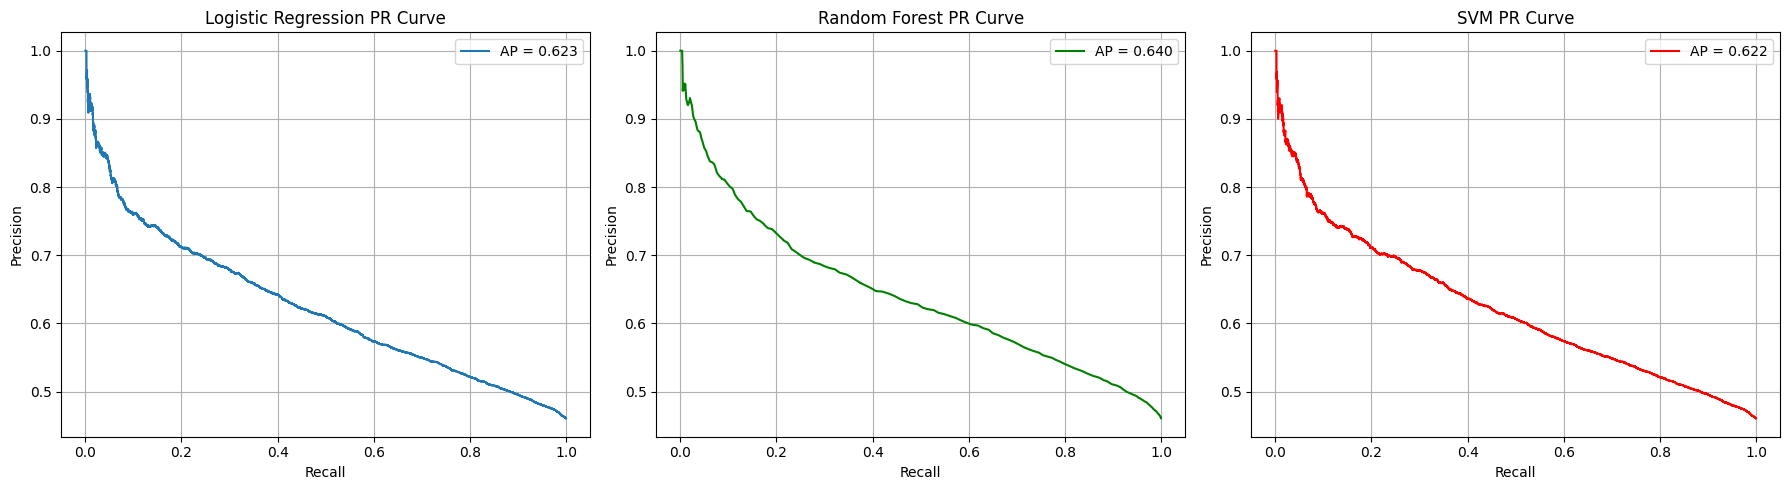

In [31]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(1,3, figsize=(18,5))

#for Logistic Regression
plt.subplot(1, 3, 1)
prec_LR, rec_LR, _ = precision_recall_curve(y_test, y_pred_prob_LogReg[:,1])
ap_LR = average_precision_score(y_test, y_pred_prob_LogReg[:,1])
plt.plot(rec_LR, prec_LR, label=f"AP = {ap_LR:.3f}")
plt.title("Logistic Regression PR Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.legend()

#Random Forest
plt.subplot(1, 3, 2)
prec_RF, rec_RF, _ = precision_recall_curve(y_test, y_proba_RFC[:,1])
ap_RF = average_precision_score(y_test, y_proba_RFC[:,1])
plt.plot(rec_RF, prec_RF, label=f"AP = {ap_RF:.3f}", color='green')
plt.title("Random Forest PR Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.legend()

# SVM
plt.subplot(1, 3, 3)
prec_SVM, rec_SVM, _ = precision_recall_curve(y_test, y_proba_SVM[:,1])
ap_SVM = average_precision_score(y_test, y_proba_SVM[:,1])
plt.plot(rec_SVM, prec_SVM, label=f"AP = {ap_SVM:.3f}", color='red')
plt.title("SVM PR Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


#higher curve = better precision at each recall level
#AP score is a one-number summary of the graph
#result shows random forest has better performance than the other two.

* Step 5.2.2: Classification Report

In [ ]:
from sklearn.utils.multiclass import unique_labels
#print(unique_labels(y_test)) [0 1] tells us the order in which the data is generated, useful for mapping target names
for model_name, prediction in models.items():
    print('Model Name:\n',model_name)
    class_report = classification_report(y_true = y_test, y_pred = prediction,labels=unique_labels(y_test), target_names= ['Not Readmitted','Readmitted'])
    print(class_report)

Model Name:
 Logistic Regression
                precision    recall  f1-score   support

Not Readmitted       0.61      0.80      0.69     10973
    Readmitted       0.64      0.41      0.50      9381

      accuracy                           0.62     20354
     macro avg       0.62      0.60      0.60     20354
  weighted avg       0.62      0.62      0.60     20354

Model Name:
 Random Forest
                precision    recall  f1-score   support

Not Readmitted       0.64      0.71      0.68     10973
    Readmitted       0.62      0.54      0.57      9381

      accuracy                           0.63     20354
     macro avg       0.63      0.63      0.63     20354
  weighted avg       0.63      0.63      0.63     20354

Model Name:
 SVM
                precision    recall  f1-score   support

Not Readmitted       0.61      0.79      0.69     10973
    Readmitted       0.63      0.41      0.50      9381

      accuracy                           0.62     20354
     macro avg     

* Step 5.3: ROC-AUC Curve

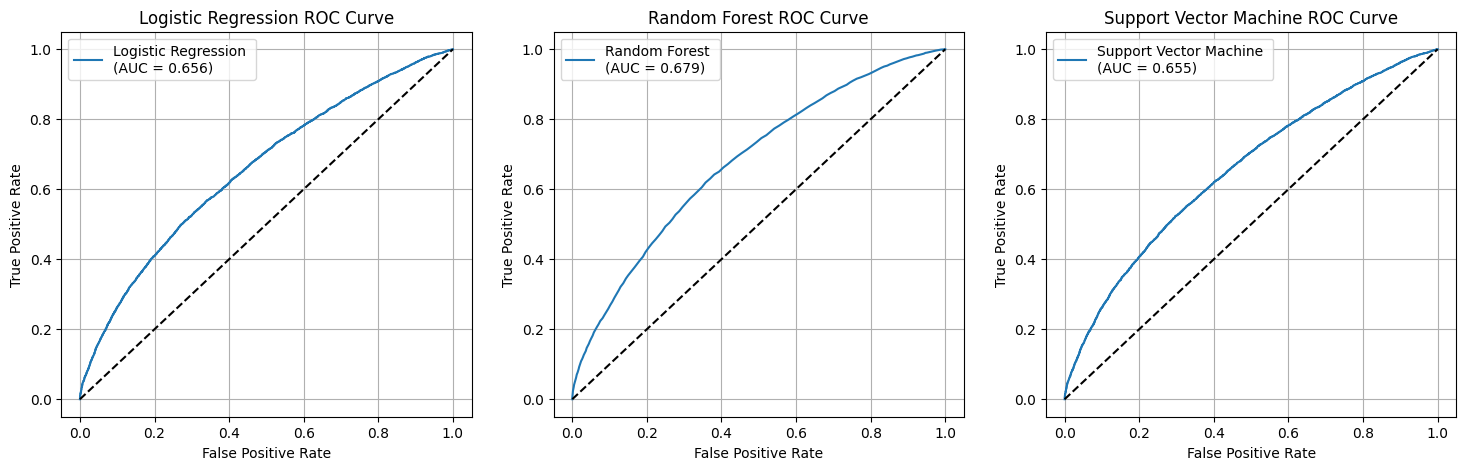

In [41]:
from sklearn.metrics import roc_auc_score, roc_curve, auc

fig, ax = plt.subplots(1,3, figsize=(18,5))

#for Logistic regression
plt.subplot(1,3,1)
fpr_LR, tpr_LR, _ = roc_curve(y_test, y_pred_prob_LogReg[:,1]) #plotting false positive rate versus true positive rate
auc_LR = auc(fpr_LR, tpr_LR) #getting the area under the curve using FPR and TPR
plt.plot(fpr_LR, tpr_LR, label=f"Logistic Regression \n(AUC = {auc_LR:.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.title("Logistic Regression ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend()

#for random forest
plt.subplot(1,3,2)
fpr_RF, tpr_RF, _ = roc_curve(y_test, y_proba_RFC[:,1]) #plotting false positive rate versus true positive rate
auc_RF = auc(fpr_RF, tpr_RF) #getting the area under the curve using FPR and TPR
plt.plot(fpr_RF, tpr_RF, label=f"Random Forest \n(AUC = {auc_RF:.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.title("Random Forest ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend()

#for SVM
plt.subplot(1,3,3)
fpr_SVM, tpr_SVM, _ = roc_curve(y_test, y_proba_SVM[:,1]) #plotting false positive rate versus true positive rate
auc_SVM = auc(fpr_SVM, tpr_SVM) #getting the area under the curve using FPR and TPR
plt.plot(fpr_SVM, tpr_SVM, label=f"Support Vector Machine \n(AUC = {auc_SVM:.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.title("Support Vector Machine ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend()

# Step 6: Final Comparison Table

In [47]:
final_result = {
    'LogisticRegression': (y_pred_LogReg, y_pred_prob_LogReg[:,1]),
    "Random Forest": (y_pred_RFC,y_proba_RFC[:,1]),
    "SVM": (y_pred_SVM, y_proba_SVM[:,1])
}

comparison_table = {
    'Model':[],
    'True Positive' : [],
    'True Negative' : [],
    'False Positive': [],
    'False Negative':[],
    'Accuracy':[],
    'Precision':[],
    'Recall':[],
    'F1 Score':[],
    'ROC-AUC':[],
    'Average Precision':[]
}


for name, (prediction,probs) in final_result.items():

    tn, fp, fn, tp = confusion_matrix(y_test, prediction).ravel() #compute confusion matrix
    comparison_table['Model'].append(name)
    comparison_table['True Positive'].append(tp)
    comparison_table['True Negative'].append(tn)
    comparison_table['False Positive'].append(fp)
    comparison_table['False Negative'].append(fn)
    comparison_table['Accuracy'].append(accuracy_score(y_test,prediction))
    comparison_table['Precision'].append(precision_score(y_test,prediction))
    comparison_table['Recall'].append(recall_score(y_test,prediction))
    comparison_table['F1 Score'].append(f1_score(y_test,prediction))
    comparison_table["ROC-AUC"].append(roc_auc_score(y_test, probs))
    comparison_table["Average Precision"].append(average_precision_score(y_test, probs))


comparisonTable_df = pd.DataFrame(comparison_table)
comparisonTable_df


,Model,True Positive,True Negative,False Positive,False Negative,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision
0,LogisticRegression,3855,8759,2214,5526,0.619731,0.635195,0.410937,0.499029,0.656255,0.622993
1,Random Forest,5038,7829,3144,4343,0.632161,0.615742,0.537043,0.573706,0.678742,0.639883
2,SVM,3891,8706,2267,5490,0.618896,0.631861,0.414775,0.500804,0.655210,0.621758


# Final results indicate that the Random Forest Classifier has the highest overall accuracy and average precision as compared to the other two models. Although, the accuracy percentages are low for all three but the F1 score sets the three models apart.